# Study Summary Info:

## Module 02: Lesson 01 --- Word Translation Entropy

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Critt-Kent/CRITT-Academy/blob/main/modules/01_Foundations/02_Summary_Info.ipynb) | [This video linked here](https://vimeo.com/1201603642) explains how to use this code notebook in Google Colab 🤠

### What You Will Do In This Lesson

Entropy-related values are computed on a word level for each study. They can be re-computes for several studies, increasing the accuracy of the values, or on a fraction of a study. 

1. Recompute entropy-related values on a word level for ST tables across several studies:
   - `HTra`: word translation Entropy
   - `HTraN`: normalized `HTra`
   - `InfT`: word translation information $log(1/P(\text{translation}))$
   - `InfS`: grouping probability: Probability to cluster ST words for the translation
     
2. Carry over the word-based values to the segment level to compute:
    - `HTraN`: average normalized `HTraN`
    - `HTot`: sum over word-based `HTra` values values
    - `InfT`: mean word-based `InfT` values
    - `InfS`: mean word-based `InfS` values
      
4. Carry over the word-based `HTra`, `HTraN`, `InfS`, and `InfT` to other kinds of units, e.g., `PUs`, `AUs` 

### First time working with a CRITT Academy code notebook?

If you haven't yet gone through the [CRITT Academy Module 01, Lesson 01, “Code Notebooks and the TPR_DB”](https://github.com/Critt-Kent/CRITT-Academy/blob/main/modules/01_Foundations/01_Notebooks_and_TPRDB.ipynb), you should do that first (this will help you understand Steps 1 through 3 much better).

## Step 1. Import all necessary Python libraries


In [ ]:
# Environment Setup
import sys
from importlib.metadata import version, PackageNotFoundError
from packaging.version import Version

# Enforce a minimum Python version of 3.9+
if sys.version_info < (3, 9):
    raise RuntimeError(
        f"❌ Python 3.9 or higher is required. "
        f"You are currently running Python {sys.version_info.major}.{sys.version_info.minor}."
    )

REQUIRED = {
    "numpy": "2.4.0",
    "pandas": "3.0.0",
    "scipy": "1.17.0",
    "matplotlib": "3.10.0",
    "seaborn": "0.13.0",
    "tprdb-utilities": "0.3.0",
}

def _check_versions():
    outdated = []
    for pkg, min_ver in REQUIRED.items():
        try:
            installed = version(pkg)
            if Version(installed) < Version(min_ver):
                outdated.append(f"  {pkg}: installed {installed}, need >={min_ver}")
        except PackageNotFoundError:
            raise ImportError(f"{pkg} is not installed")
    return outdated

# Check if dependencies are missing and install them automatically
try:
    import numpy as np
    import pandas as pd
    import scipy.stats
    import matplotlib.pyplot as plt
    import seaborn as sns
    import tprdb_utilities

    outdated = _check_versions()
    if outdated:
        raise ImportError("Outdated packages:\n" + "\n".join(outdated))
    else:
        print("🤠 All core dependencies are already installed. You are ready to go! 🤘")
except ImportError:
    print("Missing dependencies detected. Installing required packages...")

    try:
        # The %pip magic ensures installation happens in the active Jupyter kernel
        %pip install "numpy>=2.4.0" "pandas>=3.0.0" "scipy>=1.17.0" "matplotlib>=3.10.0" "seaborn>=0.13.0" "tprdb-utilities>=0.3.0"

        print("\n🤠 Installation complete 🤘 If imports fail on the next cell, please restart the kernel.")
    except Exception as e:
        print(f"❌ An error occurred during installation: {e}")
        print("If using Google Colab, you may just have to restart your runtime now to use the newly installed packages.")

In [11]:
# When working on the CRITT server: set the path to the tprdb_utilities directory:

import sys
TPR_utils = '/data/'
sys.path.append(f"{TPR_utils}/tprdb-utilities/src")  # point to the folder that CONTAINS the package


In [12]:
# Now, import the libraries

try:
    # Standard Python library imports
    import glob
    import os
    import re

    import numpy as np
    import pandas as pd
    import scipy.stats
    import matplotlib
    import matplotlib.pyplot as plt
    import seaborn as sns

    # TPR-DB utilities import
    from tprdb_utilities import fetch_TPRDB_tables, read_TPRDB_tables

    print("✅ All imports successful!")

except ImportError as e:
    print(f"❌ An error occurred during imports: {e}")
    print("Please ensure all dependencies are installed and the kernel is restarted if necessary.")

✅ All imports successful!


## Step 2: Fetch Tables Data


In [5]:
# Commenting/Uncommenting Code: ⌘ + / (Mac) or Ctrl + / (Windows/Linux)

# 🫵 If NOT using Google Colab:
# 1) Change what's in the quotes below ("./") to point to where you want your mothership clone to be saved.
# 2) Then, run this code cell
mothership_clone_location = "./"

# 🫵 when using on the CRITT server:
mothership_clone_location = "/data/critt/tprdb/"

# 🫵 If using Google Colab:
# 1) Comment out the above line of code
# 2) Uncomment the lines of code below
# 3) Then, run this code cell

# from google.colab import drive
# drive.mount('/content/drive')
# mothership_clone_location = "/content/drive/MyDrive/"

In [ ]:
# fetch data tables (notice we are using the `mothership_clone_location` variable we defined in the cell above)

fetch_TPRDB_tables(
    path=mothership_clone_location,
    StudyID="TB24",
    extensions=["ss"],
    public=True,
)

## Step 3a: Read ST data from different studies into a DataFrame

When the studies have the same source text and identical language pairs, we can re-compute the entropy values based on the joint dataset. 


In [28]:
# these studies use (English) Multiling texts translation into Chinese
studies=["RUC17", "RUCMT17", "STML18bolt", "HNUJml", "STC17bolt", "ZHMT19", "MS12"]

# read the session data into a DataFrame

tprdb_path=f'{mothership_clone_location}/tprdb-mothership-clone'

# uncomment when when working on the CRITT server
tprdb_path=f'{mothership_clone_location}'


In [14]:


# read the Segments (SG)
STdf = read_TPRDB_tables(
    path=tprdb_path,
    user='PUBLIC',
    studies=studies,
    extension="st",
    verbose=1,
)


Reading: RUC17	with 124 'st' Tables
Reading: RUCMT17	with 96 'st' Tables
Reading: STML18bolt	with 50 'st' Tables
Reading: HNUJml	with 59 'st' Tables
Reading: STC17bolt	with 96 'st' Tables
Reading: ZHMT19	with 78 'st' Tables
Reading: MS12	with 44 'st' Tables
Total 'st' data rows: 77985, columns: 91


<Axes: xlabel='Task', ylabel='count'>

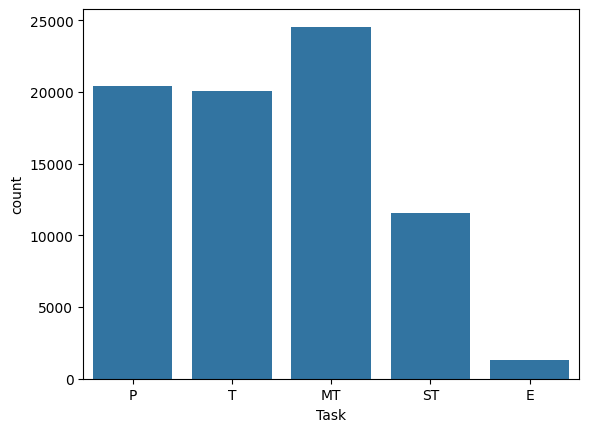

In [23]:
# check distribution of tasks in the dataframe

sns.countplot(STdf, x="Task")

### Recompute joint entropy values over all sessions


In [19]:
from tprdb_utilities.transformer import ST_entropy_df  # import the function from module

# Recompute joint entropy values for all studies
ST = ST_entropy_df(STdf, Verbose = 1)

# see the heading of the dataftame with all colums
pd.set_option('display.max_columns', 500)
ST.head()

Source Texts 5 with instances 81 
Source Texts 1 with instances 108 
Source Texts 6 with instances 79 
Source Texts 2 with instances 113 
Source Texts 4 with instances 85 
Source Texts 3 with instances 81 


,Id,Study,Session,StudySession,SL,TL,Task,Text,Part,SToken,SGroup,Lemma,STid,SGid,STseg,Cur,TGroup,TTid,TGid,TTseg,Ins,Del,InEff,Dur,pos,upos,xpos,feats,head,deprel,ner,multi_ner,FixS,TrtS,OrtS,OrtT,MU1rtS,MU1rtT,FFTimeS,FFDurS,FixT,TrtT,FFTimeT,FFDurT,Annot,Munit,STime,SDur,Pause1,Time1,Dur1,End1,Ins1,Del1,Edit1,Pause2,Time2,Dur2,Ins2,Del2,Edit2,PauseR,TimeR,DurR,InsR,DelR,EditR,Edit,Cross,AUid,Count,AltT,ProbT,InfT,HTra,HTraN,AltS,ProbS,InfS,HSgrp,HSgrpN,AltC,ProbC,InfC,HCross,HCrossN,AltSTC,ProbSTC,InfSTC,HSTC,HSTCN
0,1,RUCMT17,P01_MT5,RUCMT17@P01_MT5,en,zh,MT,5,P01,Sociology,Sociology,sociology,1,1,1,0,社会学,1,1,1,0,0,0.0,0,NN,NOUN,NN,Number=Sing,7,nsubj,O,"('O',)",0,0,0,0,0,0,0,0,0,0,0,0,---,0,---,---,0,0,0,0,0,0,---,0,0,0,0,0,---,0,0,0,0,0,0,0,1,---,77,3,0.975309,0.025001,0.132889,0.020961,3,0.975309,0.025001,0.132889,0.020961,2,0.975309,0.025001,0.115774,0.018261,5,0.950617,0.050644,0.265153,0.041823
1,2,RUCMT17,P01_MT5,RUCMT17@P01_MT5,en,zh,MT,5,P01,is,is,be,2,2,1,10,是,2,2,1,0,0,0.0,0,VBZ,AUX,VBZ,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbF...,7,cop,O,"('O',)",0,0,0,0,0,0,0,0,0,0,0,0,---,0,---,---,0,0,0,0,0,0,---,0,0,0,0,0,---,0,0,0,0,0,0,0,1,---,73,4,0.938272,0.063716,0.290356,0.045799,3,0.938272,0.063716,0.262586,0.041418,3,0.950617,0.050644,0.224463,0.035405,6,0.901235,0.10399,0.469935,0.074124
2,3,RUCMT17,P01_MT5,RUCMT17@P01_MT5,en,zh,MT,5,P01,a,a,a,3,3,1,13,一个,3,3,1,0,0,0.0,0,DT,DET,DT,Definite=Ind|PronType=Art,7,det,O,"('O',)",0,0,0,0,0,0,0,0,0,0,0,0,---,0,---,---,0,0,0,0,0,0,---,0,0,0,0,0,---,0,0,0,0,0,0,0,1,---,21,8,0.283951,1.258955,1.171594,0.184798,4,0.901235,0.10399,0.42505,0.067044,5,0.296296,1.216395,1.064735,0.167943,12,0.259259,1.349927,1.313288,0.207148
3,4,RUCMT17,P01_MT5,RUCMT17@P01_MT5,en,zh,MT,5,P01,relatively,relatively,relatively,4,4,1,15,比较,4,4,1,0,0,0.0,0,RB,ADV,RB,Degree=Pos,5,advmod,O,"('O',)",0,0,0,0,0,0,0,0,0,0,0,0,---,0,---,---,0,0,0,0,0,0,---,0,0,0,0,0,---,0,0,0,0,0,0,0,1,---,14,19,0.17284,1.755392,1.931911,0.304725,3,0.950617,0.050644,0.224463,0.035405,6,0.259259,1.349927,1.064036,0.167833,24,0.17284,1.755392,2.150826,0.339255
4,5,RUCMT17,P01_MT5,RUCMT17@P01_MT5,en,zh,MT,5,P01,new,new,new,5,5,1,26,新_的,5,5+6,1,0,0,0.0,0,JJ,ADJ,JJ,Degree=Pos,7,amod,O,"('O',)",0,0,0,0,0,0,0,0,0,0,0,0,---,0,---,---,0,0,0,0,0,0,---,0,0,0,0,0,---,0,0,0,0,0,0,0,2,---,51,15,0.654321,0.424157,1.461486,0.230524,3,0.950617,0.050644,0.224463,0.035405,8,0.740741,0.300105,0.950388,0.149907,20,0.62963,0.462624,1.641542,0.258924


### Visualize entropy values

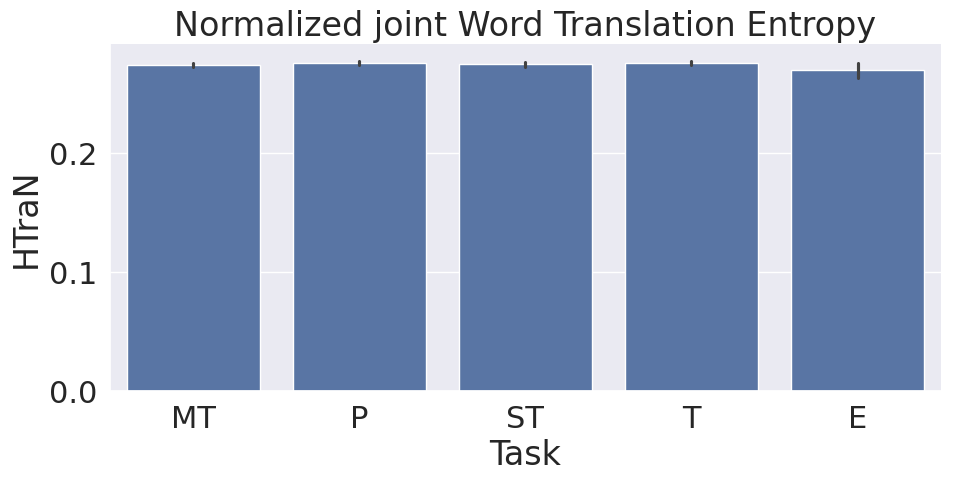

In [39]:
# plot Histogram
ax4 = sns.catplot(x="Task",
                 y="HTraN",
                 kind="bar",
                 data=ST,
                 height=5,
                 aspect=2
                )

# add labels
ax4.set(ylabel='HTraN', xlabel='Task', title='Normalized joint Word Translation Entropy')
plt.show()

### Recompute entropy values per task

In [25]:
# Recompute entropy values per Task
# -- task 'E' has too few occurrances

STdf_P = STdf[STdf['Task'] == 'P'] 
STdf_T = STdf[STdf['Task'] == 'T'] 
STdf_M = STdf[STdf['Task'] == 'MT'] 
STdf_S = STdf[STdf['Task'] == 'ST'] 

print("Post-editing sessions:")
STp = ST_entropy_df(STdf_P, Verbose = 1)

print("Translation sessions:")
STt = ST_entropy_df(STdf_T, Verbose = 1)

print("Machine Translation sessions:")
STm = ST_entropy_df(STdf_M, Verbose = 1)

print("Sight Translation sessions:")
STs = ST_entropy_df(STdf_S, Verbose = 1)


print(STp.shape, STt.shape, STm.shape, STs.shape)

Post-editing sessions:
Source Texts 5 with instances 17 
Source Texts 1 with instances 31 
Source Texts 6 with instances 15 
Source Texts 4 with instances 21 
Source Texts 2 with instances 36 
Source Texts 3 with instances 22 
Translation sessions:
Source Texts 5 with instances 19 
Source Texts 2 with instances 33 
Source Texts 4 with instances 18 
Source Texts 3 with instances 17 
Source Texts 6 with instances 18 
Source Texts 1 with instances 34 
Machine Translation sessions:
Source Texts 2 with instances 29 
Source Texts 5 with instances 29 
Source Texts 3 with instances 29 
Source Texts 1 with instances 29 
Source Texts 6 with instances 29 
Source Texts 4 with instances 29 
Sight Translation sessions:
Source Texts 6 with instances 15 
Source Texts 3 with instances 12 
Source Texts 4 with instances 13 
Source Texts 1 with instances 14 
Source Texts 2 with instances 14 
Source Texts 5 with instances 14 
(20438, 91) (20094, 91) (24563, 91) (11595, 91)


### Visualize segment-based entropy values

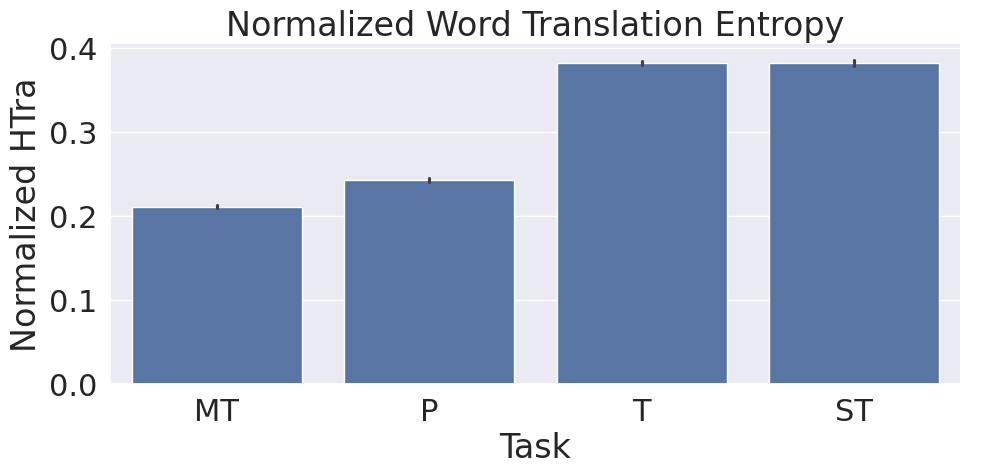

In [26]:
# concatenate dataframes of the individual tasks
STdf_2 = pd.concat([STm, STp, STt, STs])

# set font and figure size 
plt.rcParams["figure.figsize"] = (10,10)
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20)
sns.set(font_scale = 2)

# plot Histogram
ax4 = sns.catplot(x="Task",
                 y="HTraN",
                 kind="bar",
                 data=STdf_2,
                 height=5,
                 aspect=2
                )

# add labels
ax4.set(ylabel='Normalized HTra', xlabel='Task', title='Normalized Word Translation Entropy')
plt.show()

## Step 3b: Read SG data from different studies

In [27]:
# read the session data into a DataFrame

extension="sg"

SGdf = read_TPRDB_tables(
    path= tprdb_path,
    user='PUBLIC',
    studies=studies,
    extension=extension,
    verbose=1,
)



Reading: RUC17	with 124 'sg' Tables
Reading: RUCMT17	with 96 'sg' Tables
Reading: STML18bolt	with 50 'sg' Tables
Reading: HNUJml	with 59 'sg' Tables
Reading: STC17bolt	with 96 'sg' Tables
Reading: ZHMT19	with 78 'sg' Tables
Reading: MS12	with 44 'sg' Tables
Total 'sg' data rows: 3789, columns: 39


### Recompute joint entropy values per segment

In [46]:
# Compute SG entropy values based on joint re-computed ST entropy 
from tprdb_utilities.transformer import SG_entropy_df  # import function from the module

# compute segment-based entropy based on word-based entropy values
SG = SG_entropy_df(SGdf, ST, Verbose = 1)

# see the heading of the dataftame with all colums
pd.set_option('display.max_columns', 500)
SG.head(2)

Text Id:3	Texts:60
Text Id:6	Texts:58
Text Id:4	Texts:61
Text Id:1	Texts:87
Text Id:5	Texts:60
Text Id:2	Texts:91


,Id,Study,Session,StudySession,SL,TL,Task,Text,Part,KUI,PUB,STseg,TTseg,LenS,LenT,TokS,TokT,Ins,Del,Dur,FixS,TrtS,FixT,TrtT,Nedit,PreGap,PostGap,TB1000,TG1000,TD1000,TB_KUI,TG_KUI,TD_KUI,TB_PUB,TG_PUB,TD_PUB,String,HTot,HTotN,HTraN,InfS,InfT
0,1,RUC17,P19_T3,RUC17@P19_T3,en,zh,T,3,P19,354,4362,1,1,44,23,7,7,18,16,150891,88,44555,76,51677,2,59375,12495,23,148579,2312,24,149344,1547,11,124219,26672,斯皮尔伯格_因达尔福_事件_对_北京_出_红牌,17.248813,0.3838,0.316136,0.904654,4.040755
1,2,RUC17,P19_T3,RUC17@P19_T3,en,zh,T,3,P19,354,4362,2,2,172,73,31,26,25,2,82515,191,94524,124,68257,2,3687,73875,23,80499,2016,26,82187,328,9,46108,36407,坚决_于_中国_政府_对抗_，_斯蒂芬_斯皮尔伯格_拒绝_出席_北京_奥运会_，_以_此_来...,43.341166,0.3531,0.244417,0.942185,2.495856


### Vizualize joint segment-based entropy values

<Axes: xlabel='Task', ylabel='count'>

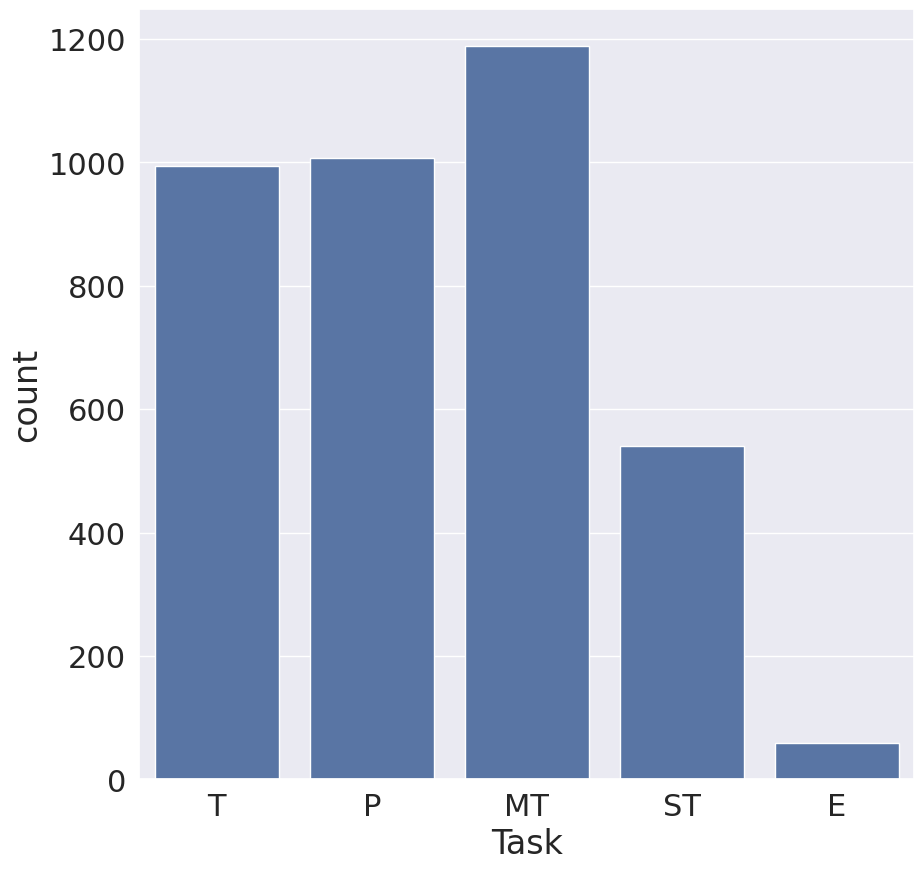

In [42]:
# check distribution of tasks in the dataframe

sns.countplot(SG, x="Task")

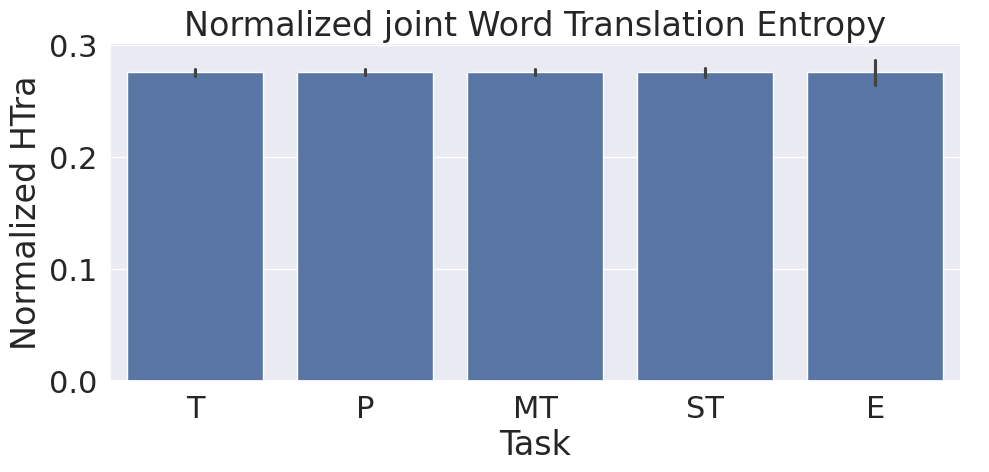

In [34]:
# plot Histogram
ax4 = sns.catplot(x="Task",
                 y="HTraN",
                 kind="bar",
                 data=SG,
                 height=5,
                 aspect=2
                )

# add labels
ax4.set(ylabel='Segment-based HTraN', xlabel='Task', title='Normalized joint Word Translation Entropy')
plt.show()

### Recompute SG entropy values per Task

In [49]:
# Recompute entropy values per Task
# -- task 'E' has too few occurrances

SG_P = SG[SG['Task'] == 'P'].copy() 
SG_T = SG[SG['Task'] == 'T'].copy() 
SG_M = SG[SG['Task'] == 'MT'].copy() 
SG_S = SG[SG['Task'] == 'ST'].copy() 

print("Post-editing sessions:")
SGp = SG_entropy_df(SG_P, STp, Verbose = 1)

print("Translation sessions:")
SGt = SG_entropy_df(SG_T, STt, Verbose = 1)

print("Machine Translation sessions:")
SGm = SG_entropy_df(SG_M, STm, Verbose = 1)

print("Sight Translation sessions:")
SGs = SG_entropy_df(SG_S, STs, Verbose = 1)


print(SGp.shape, SGt.shape, SGm.shape, SGs.shape)

Post-editing sessions:
Text Id:4	Texts:16
Text Id:3	Texts:18
Text Id:1	Texts:27
Text Id:5	Texts:13
Text Id:6	Texts:11
Text Id:2	Texts:32
Translation sessions:
Text Id:3	Texts:12
Text Id:6	Texts:13
Text Id:1	Texts:29
Text Id:5	Texts:14
Text Id:2	Texts:27
Text Id:4	Texts:11
Machine Translation sessions:
Text Id:4	Texts:19
Text Id:5	Texts:19
Text Id:2	Texts:19
Text Id:6	Texts:19
Text Id:3	Texts:19
Text Id:1	Texts:19
Sight Translation sessions:
Text Id:1	Texts:12
Text Id:6	Texts:13
Text Id:5	Texts:12
Text Id:2	Texts:12
Text Id:3	Texts:10
Text Id:4	Texts:11
(1007, 42) (994, 42) (1189, 42) (541, 42)


In [ ]:
# concatenate dataframes of the individual tasks
SGdf_2 = pd.concat([SGm, SGp, SGt, SGs])

### Visualize task-adjusted entropy values per segment

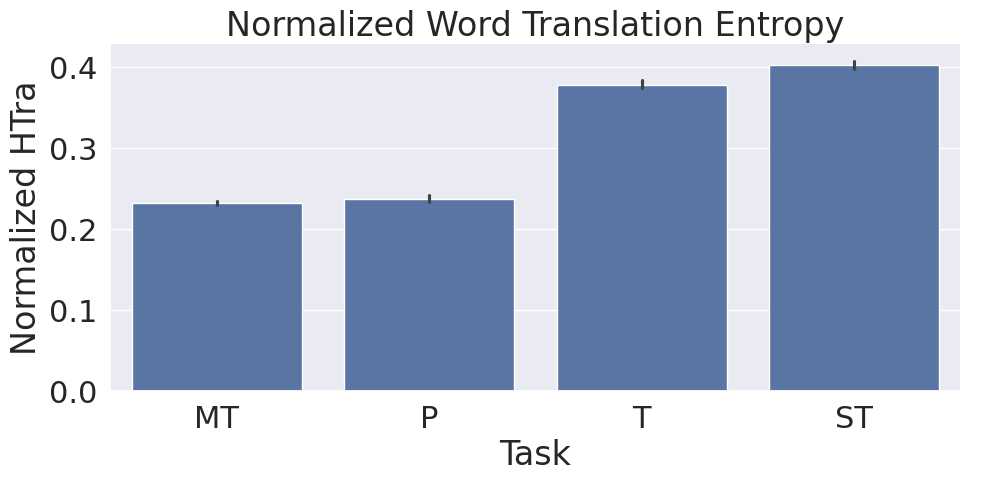

In [ ]:
# set font and figure size 
plt.rcParams["figure.figsize"] = (10,10)
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20)
sns.set(font_scale = 2)

# plot Histogram
ax4 = sns.catplot(x="Task",
                 y="HTraN",
                 kind="bar",
                 data=SGdf_2,
                 height=5,
                 aspect=2
                )

# add labels
ax4.set(ylabel='Normalized HTra', xlabel='Task', title='Normalized Word Translation Entropy')
plt.show()

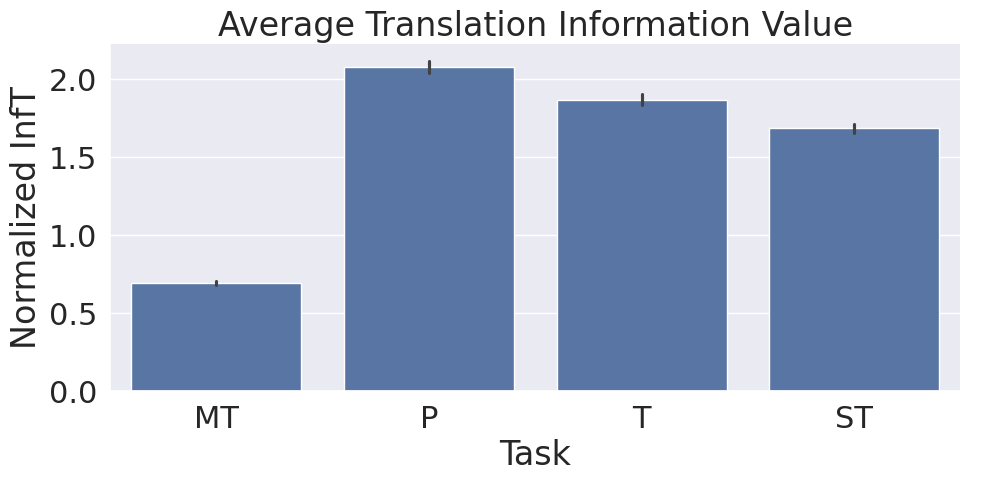

In [52]:
# set font and figure size 
plt.rcParams["figure.figsize"] = (10,10)
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20)
sns.set(font_scale = 2)

# plot Histogram
ax4 = sns.catplot(x="Task",
                 y="InfT",
                 kind="bar",
                 data=SGdf_2,
                 height=5,
                 aspect=2
                )

# add labels
ax4.set(ylabel='Average InfT', xlabel='Task', title='Average Translation Information Value (InfT)')
plt.show()

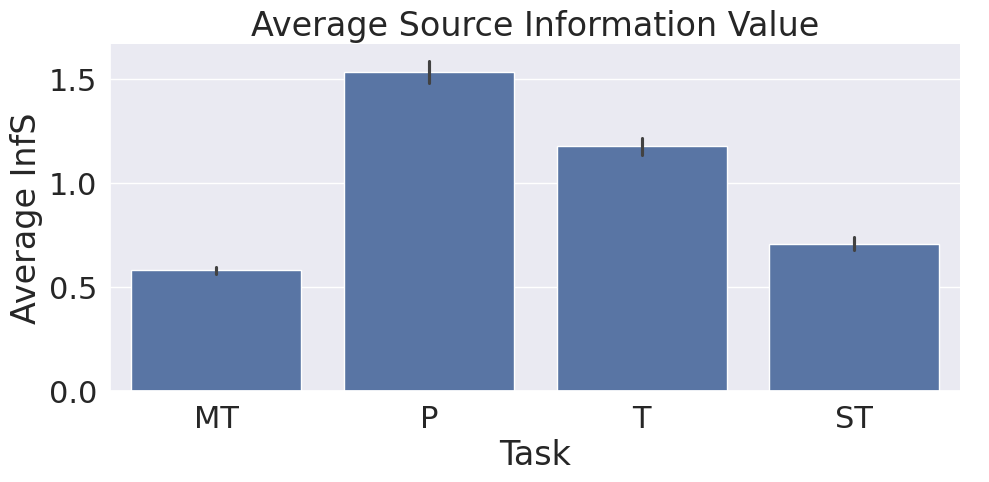

In [59]:
# set font and figure size 
plt.rcParams["figure.figsize"] = (10,10)
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20)
sns.set(font_scale = 2)

# plot Histogram
ax = sns.catplot(x="Task",
                 y="InfS",
                 kind="bar",
                 data=SGdf_2,
                 height=5,
                 aspect=2
                )

# add labels
ax.set(ylabel='Average InfS', xlabel='Task', title='Average Source Information Value')
plt.show()

## Step 3c: Translation entropy values for PUs

In [55]:
# read the PU data for translation sessions


PUdf = read_TPRDB_tables(
    path= tprdb_path,
    user='PUBLIC',
    studies=studies,
    extension="pu",
    verbose=1,
)

print("Number of rows and columns:", PUdf.shape)


Reading: RUC17	with 124 'pu' Tables
Reading: RUCMT17	with 96 'pu' Tables
Reading: STML18bolt	with 50 'pu' Tables
Reading: HNUJml	with 59 'pu' Tables
Reading: STC17bolt	with 96 'pu' Tables
Reading: ZHMT19	with 78 'pu' Tables
Reading: MS12	with 44 'pu' Tables
Total 'pu' data rows: 16556, columns: 37
Number of rows and columns: (16556, 37)


### Compute average entropy values per PU from joint ST HTraN values

In [56]:
# Compute entropy values for all PUs based on re-computed HTra values
from tprdb_utilities.transformer import DF_entropy_df  # import function from the module

PU = DF_entropy_df(PUdf, ST, Verbose = 1)


# see the heading of the dataftame with all colums
pd.set_option('display.max_columns', 500)
PU.head(2)

Text Id:2	Texts:77
Text Id:5	Texts:47
Text Id:1	Texts:74
Text Id:3	Texts:47
Text Id:6	Texts:44
Text Id:4	Texts:46


,Id,Study,Session,StudySession,SL,TL,Task,Text,Part,KUI,PUB,Time,Dur,End,Pause,Type,WinSwitch,FixS,TrtS,FixT,TrtT,TUfxS,TUrtS,TUfxT,TUrtT,TimeTU,DurTU,Phase,Ins,Del,Strokes,STseg,TTseg,SGid,TGid,Edit,AUid,HTot,HTraN,InfS,InfT
0,1,RUC17,P21_P2,RUC17@P21_P2,en,zh,P,2,P21,314,2640,16015,3110,19125,16015,C,6,0,0,2,1925,10,6292,10,5815,0,19125,D,4,4,8,1,1,1,1,shou[uohs,1+2+3+4+5+6+7+8+9+10+11+12+13+14+15+16+17+18+1...,0.832967,0.122133,0.036040,0.184093
1,2,RUC17,P21_P2,RUC17@P21_P2,en,zh,P,2,P21,314,2640,22172,0,22172,3047,I,0,0,0,0,0,0,0,0,0,19125,3047,D,1,0,7,1,1,3,2,受到,24+25,3.287825,0.482073,1.954799,4.034241


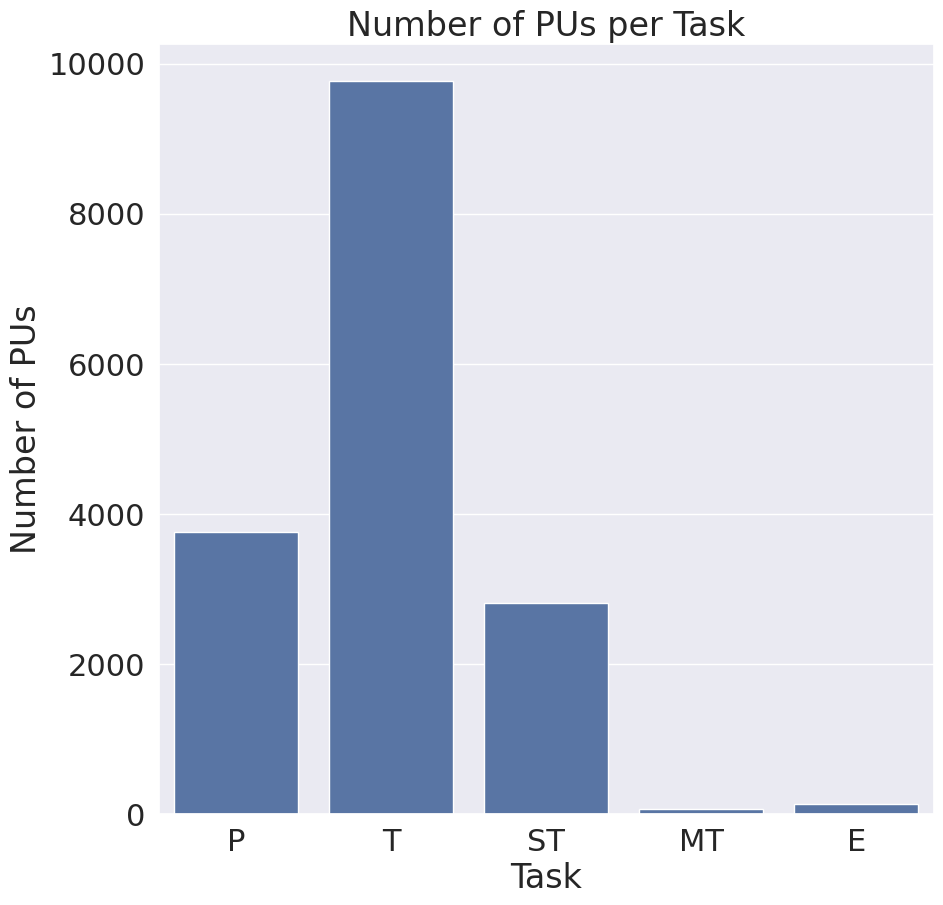

In [60]:
# check distribution of tasks in the dataframe

ax = sns.countplot(PU, x="Task" )

# add labels
ax.set(ylabel='Number of PUs', xlabel='Task', title='Number of PUs per Task')
plt.show()

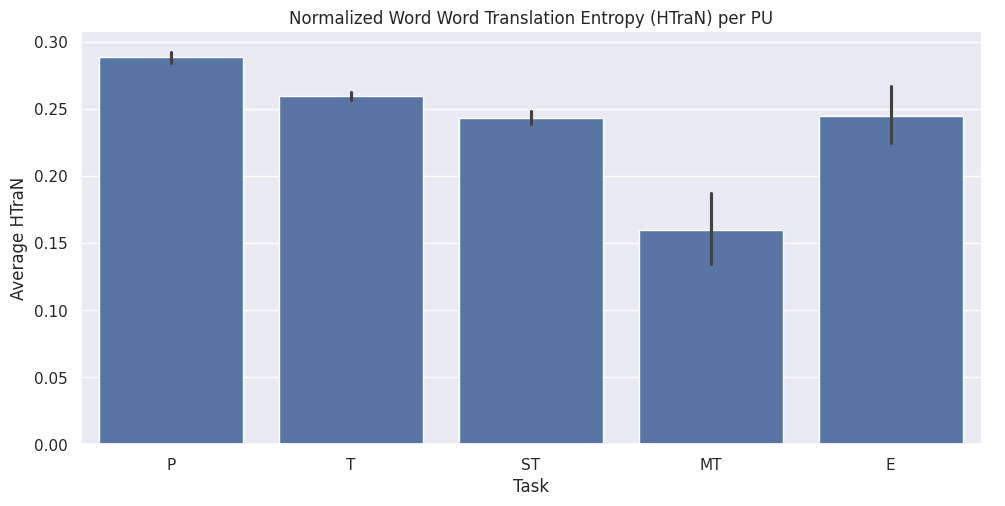

In [61]:

# plot data
# set font and figure size 
plt.rcParams["figure.figsize"] = (10,10)
matplotlib.rc('xtick', labelsize=10) 
matplotlib.rc('ytick', labelsize=10)
sns.set(font_scale = 1)


ax4 = sns.catplot(x="Task",
                 y="HTraN",
                 kind="bar",
                 data=PU,
                 height=5,
                 aspect=2
                )

# add labels
ax4.set(ylabel='Average HTraN', xlabel='Task', title='Normalized Word Word Translation Entropy (HTraN) per PU')
plt.show()



### Recompute entropy values per task

In [63]:
# Recompute entropy values per Task
# -- task 'E' and MT hava too few occurrances

PU_P = PU[PU['Task'] == 'P'].copy() 
PU_T = PU[PU['Task'] == 'T'].copy() 
PU_S = PU[PU['Task'] == 'ST'].copy() 

print("Post-editing sessions:")
PUp = DF_entropy_df(PU_P, STp, Verbose = 1)

print("Translation sessions:")
PUt = DF_entropy_df(PU_T, STt, Verbose = 1)

print("Sight Translation sessions:")
PUs = DF_entropy_df(PU_S, STs, Verbose = 1)


print(PUp.shape, PUt.shape, PUs.shape)

Post-editing sessions:
Text Id:2	Texts:32
Text Id:1	Texts:27
Text Id:5	Texts:13
Text Id:6	Texts:11
Text Id:4	Texts:16
Text Id:3	Texts:18
Translation sessions:
Text Id:5	Texts:14
Text Id:3	Texts:12
Text Id:4	Texts:11
Text Id:1	Texts:29
Text Id:6	Texts:13
Text Id:2	Texts:27
Sight Translation sessions:
Text Id:4	Texts:11
Text Id:3	Texts:10
Text Id:5	Texts:12
Text Id:1	Texts:12
Text Id:2	Texts:12
Text Id:6	Texts:13
(3758, 41) (9771, 41) (2818, 41)


In [65]:
# concatenate dataframes of the individual tasks
PUdf_2 = pd.concat([PUp, PUt, PUs])

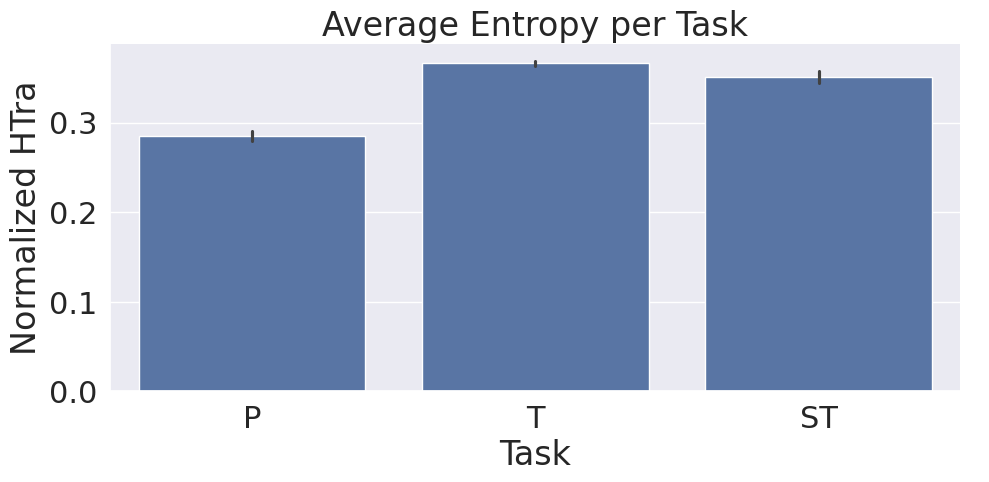

In [67]:
# set font and figure size 
plt.rcParams["figure.figsize"] = (10,10)
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20)
sns.set(font_scale = 2)

# plot Histogram
ax = sns.catplot(x="Task",
                 y="HTraN",
                 kind="bar",
                 data=PUdf_2,
                 height=5,
                 aspect=2
                )

# add labels
ax.set(ylabel='Normalized HTra', xlabel='Task', title='Average Entropy per Task')
plt.show()

# Step 4: Helper functions

In [8]:
# compute entropy values 
def ST_entropy_df(DF, Verbose = 1) :

    # associate text IDs with list of sessions
    STfiles = SortTextsInStudy_df(DF['Session'].unique())

    L = []
    # loop over text IDs
    for textID in STfiles:

        # store sntropy counts in HTRA 
        HTRA, STables, Error = ST_countValues_df(DF, STfiles[textID], Verbose = Verbose)

        if(Error) : 
            print(f"ERROR: different Source Texts {textID} : Entropy values cannot be added!")
            continue

            
        if(Verbose) : 
            cnt = 0
            if (1 in HTRA) : cnt = HTRA[1]['cnt']
                
            print(f"Source Texts {textID} with instances {cnt} ")
            
        # produce entropy columns for the entire study and each session
        SCcolumns = ST_entropy_values(HTRA)
    
        for session in STables:
            if(session not in SCcolumns):
                print("Warning ST_entropy:", session)
                continue

            # map into dataframe
            df = pd.DataFrame(SCcolumns[session]).T

            # if take out redundant columns
            cols = list(df.columns)
            if('SToken' in cols) : cols.remove('SToken')

            # delete double columns in STables that are already available
            df2 = STables[session].drop(columns=cols, errors='ignore')
            df2 = df2.drop(columns=[f"{c}_x" for c in cols], errors='ignore')
            df2 = df2.drop(columns=[f"{c}_y" for c in cols], errors='ignore')

            # re-assign Id 
            df['Id'] = range(1, len(df) +1)

            # and merge
            L.append(pd.merge(df2, df, on=['Id', 'SToken'], how='inner'))

    return pd.concat(L)

# return a dictionary {text : [list_of_sessions] ... } 
def SortTextsInStudy_df(sessions) :
    """
    sessions: list of sessions
    
    """
        
    # store the list of sessions per source textId 
    # e.g.: Study[1][session1, session5 ...]
    Study = {} 

    # find how many versions per ST 
    for fn in sessions:

        session = os.path.basename(fn)
        
        # parse the filename
        match = re.search(r'_[^\d]+(\d+)', session)
        if(match) :
            # convert to int, text could be 1 or 01
            tid = int(match.group(1))
            Study.setdefault(tid, [])      
            # parse the filename 
            Study[tid].append(session)
        else:
            print("TextIdsInStudy:filename:", fn)
        
    return Study



# per ST word count values for translation, TT group, ST group 
def ST_countValues_df(DF, StudyTextID, Verbose = 0) :
    
    STable = {} # dictionary of sessions with dataframe
    HTRA = {}  # dictionary of text IDs with item counts
    ERR = {}
    for session in sorted(StudyTextID) :

        # pull out session and count frequency of items
        STable[session] = DF[DF['Session'] == session]
        
        for t in STable[session].itertuples() :
            HTRA.setdefault(t.Id, {})
            
            # check whether ST words are identical across texts
            if('ST' in HTRA[t.Id] and HTRA[t.Id]['ST'] != t.SToken) :
                if(Verbose > 2) : print(f"ERROR: Different ST texts: {fn}: seg:{t.STseg} STid:{t.STid} SToken:{t.SToken:<10}\t{HTRA[t.Id]['ST']} ")
                ERR.setdefault(session, set())
                ERR[session] = ERR[session].union({t.STseg}) 
            HTRA[t.Id]['ST'] = t.SToken
            HTRA[t.Id].setdefault('cnt', 0)
            HTRA[t.Id]['cnt'] += 1
            
            # Target Group (Translation) count
            HTRA[t.Id].setdefault('T', {})
            HTRA[t.Id]['T'].setdefault(t.TGroup, {})
            HTRA[t.Id]['T'][t.TGroup].setdefault('cnt', 0)
            HTRA[t.Id]['T'][t.TGroup]['cnt'] += 1
            HTRA[t.Id]['T'][t.TGroup].setdefault('sess', [])
            HTRA[t.Id]['T'][t.TGroup]['sess'].append(session)

            # Source Group count
            HTRA[t.Id].setdefault('S', {})
            HTRA[t.Id]['S'].setdefault(t.SGroup, {})
            HTRA[t.Id]['S'][t.SGroup].setdefault('cnt', 0)
            HTRA[t.Id]['S'][t.SGroup]['cnt'] += 1
            HTRA[t.Id]['S'][t.SGroup].setdefault('sess', [])
            HTRA[t.Id]['S'][t.SGroup]['sess'].append(session)

            #  Cross
            HTRA[t.Id].setdefault('C', {})
            HTRA[t.Id]['C'].setdefault(t.Cross, {})
            HTRA[t.Id]['C'][t.Cross].setdefault('cnt', 0)
            HTRA[t.Id]['C'][t.Cross]['cnt'] += 1
            HTRA[t.Id]['C'][t.Cross].setdefault('sess', [])
            HTRA[t.Id]['C'][t.Cross]['sess'].append(session)

            # Joint Source, Target, Cross
            STC = f"{t.SGroup}@@{t.TGroup}@@{t.Cross}"
            HTRA[t.Id].setdefault('STC', {})
            HTRA[t.Id]['STC'].setdefault(STC, {})
            HTRA[t.Id]['STC'][STC].setdefault('cnt', 0)
            HTRA[t.Id]['STC'][STC]['cnt'] += 1
            HTRA[t.Id]['STC'][STC].setdefault('sess', [])
            HTRA[t.Id]['STC'][STC]['sess'].append(session)

    for session in ERR:
        print(f"ERROR: different ST in: {session} : seg:{ERR[session]}")
        
    return (HTRA, STable, len(ERR) != 0)

def ST_entropy_values(HTRA) :
    
    # compute information values and entropy
    for tId in HTRA:
        
        # loop over every word
        for item in HTRA[tId]['T']:
            HTRA[tId]['T'][item]['P'] = HTRA[tId]['T'][item]['cnt'] / HTRA[tId]['cnt']
            HTRA[tId]['T'][item]['I'] = np.log(1/HTRA[tId]['T'][item]['P']) 
            HTRA[tId].setdefault('HTra', 0)
            # Target-group Entropy 
            HTRA[tId]['HTra'] += HTRA[tId]['T'][item]['P']  *  HTRA[tId]['T'][item]['I']
            
        for item in HTRA[tId]['S']:
            HTRA[tId]['S'][item]['P'] = HTRA[tId]['S'][item]['cnt'] / HTRA[tId]['cnt']
            HTRA[tId]['S'][item]['I'] = np.log(1/HTRA[tId]['S'][item]['P']) 
            HTRA[tId].setdefault('HSgrp', 0)
            # Source-group Entropy 
            HTRA[tId]['HSgrp'] += HTRA[tId]['S'][item]['P']  *  HTRA[tId]['S'][item]['I']
        
            
        for item in HTRA[tId]['C']:
            HTRA[tId]['C'][item]['P'] = HTRA[tId]['C'][item]['cnt'] / HTRA[tId]['cnt']
            HTRA[tId]['C'][item]['I'] = np.log(1/HTRA[tId]['C'][item]['P']) 
            HTRA[tId].setdefault('HCross', 0)
            # Cross Entropy 
            HTRA[tId]['HCross'] += HTRA[tId]['C'][item]['P']  *  HTRA[tId]['C'][item]['I']
            
        for item in HTRA[tId]['STC']:
            HTRA[tId]['STC'][item]['P'] = HTRA[tId]['STC'][item]['cnt'] / HTRA[tId]['cnt']
            HTRA[tId]['STC'][item]['I'] = np.log(1/HTRA[tId]['STC'][item]['P']) 
            HTRA[tId].setdefault('HSTC', 0)
            # joint Sgroup, Tgroup, Cross  Entropy 
            HTRA[tId]['HSTC'] += HTRA[tId]['STC'][item]['P']  *  HTRA[tId]['STC'][item]['I']

    #AltT    CountT  ProbT   HTra    AltS    ProbS   HSgrp   AltC    ProbC   HCross  AltSTC  ProbSTC HSTC
    # mapping type - entropy attribute
    E = {'T':'HTra', 'S':'HSgrp', 'C':'HCross', 'STC':'HSTC'}
    M = {}
    for tId in HTRA:
        SToken = HTRA[tId]["ST"]
        
        for tpe in E.keys(): 

            for item in HTRA[tId][tpe]:
                for s in HTRA[tId][tpe][item]['sess'] :
                    M.setdefault(s, {})
                    M[s].setdefault(tId, {})
                    M[s][tId]["SToken"] = SToken
                    M[s][tId][f"Count"] = HTRA[tId][tpe][item]['cnt'] 
                    M[s][tId][f"Alt{tpe}"] = len(HTRA[tId][tpe].keys())
                    M[s][tId][f"Prob{tpe}"] = HTRA[tId][tpe][item]['P']
                    M[s][tId][f"Inf{tpe}"] = HTRA[tId][tpe][item]['I']
                    M[s][tId][E[tpe]] = HTRA[tId][E[tpe]]
                    # normalized Entropy
                    M[s][tId][f"{E[tpe]}N"] = HTRA[tId][E[tpe]] *np.log(2)/np.log(HTRA[tId]['cnt']) 
                    
    return M

# Compute entopy for segments
def SG_entropy_df(SG, ST, Verbose = 1) :

    # make sure STseg is of same type
    ST['STseg'] = ST['STseg'].astype(str)
    SG['STseg'] = SG['STseg'].astype(str)

    # initialize entropy values
    SG['HTot'] = 0.0
    SG['HTraN'] = 0.0
    SG['InfS'] = 0.0
    SG['InfT'] = 0.0
    
    # associate text IDs with list of sessions
    TextSessions = SortTextsInStudy_df(SG['Session'].unique())

    # loop over text IDs
    for textID in TextSessions:

        if(Verbose) : print(f"Text Id:{textID}\tTexts:{len(TextSessions[textID])}")
            
        # loop over sessions per text IDs
        for session in sorted(TextSessions[textID]) :

            if(Verbose > 2) : print(f"\t{session}")
                
            # pull out session and count frequency of items
            sg = SG[SG['Session'] == session]
            st = ST[ST['Session'] == session]
                
            # print("SG_entropy1", n, H, L)
            # loop through segments
            for seg in set(sg.STseg) :
                
                N = []
                # accumulate HTraN values for segment
                for s in seg.split('+') : N.extend(st[st.STseg == s]['HTraN'])                    
                # and compute mean HTraN
                SG.loc[SG.STseg == seg, 'HTraN'] = np.mean(N) 
        
                N = []
                # accumulate HTra values for segment
                for s in seg.split('+') : N.extend(st[st.STseg == s]['HTra'])
                # and compute sum HTra
                SG.loc[SG.STseg == seg, 'HTot'] = np.sum(N) 
                
                N = []
                # accumulate InfS values for segment
                for s in seg.split('+') : N.extend(st[st.STseg == s]['InfS'])
                # and compute sum InfS
                SG.loc[SG.STseg == seg, 'InfS'] = np.mean(N) 
                
                N = []
                # accumulate InfT values for segment
                for s in seg.split('+') : N.extend(st[st.STseg == s]['InfT'])
                # and compute sum InfT
                SG.loc[SG.STseg == seg, 'InfT'] = np.mean(N)
                
    return SG
        
# Compute entopy based on ST 
def DF_entropy_df(DF, ST, Verbose = 1) :

    if ('SGid' not in DF) :
        print(f"DF_entropy_df-1: no SGid in DF: {DF.head(3)}")
        return DF
              
    # initialize entropy values
    DF['HTot'] = 0.0
    DF['HTraN'] = 0.0
    DF['InfS'] = 0.0
    DF['InfT'] = 0.0
    
    # associate text IDs with list of sessions
    TextSessions = SortTextsInStudy_df(DF['Session'].unique())

    # loop over text IDs
    for textID in TextSessions:

        if(Verbose) : print(f"Text Id:{textID}\tTexts:{len(TextSessions[textID])}")
            
        # loop over sessions per text IDs
        for session in sorted(TextSessions[textID]) :

            if(Verbose > 2) : print(f"\t{session}")
                
            # pull out session and count frequency of items
            df = DF[DF['Session'] == session]
            st = ST[ST['Session'] == session]
                
            # print("DF_entropy1", n, H, L)
            # loop through segments
            for index, unit in df.iterrows() :

                # get SGid from unit
                SGid = str(unit['SGid'])

                # no Id or not aligned
                if (SGid == '---') or (SGid == '0'):
                    if(Verbose > 1) :print(f"DF_entropy_df: {unit['StudySession']}\tId:{unit['Id']} SGid: {SGid}")
                    continue
                            
                    
                N = []
                # accumulate HTraN values from STid for unit SGid 
                for s in SGid.split('+') : N.extend(st[st.STid == int(s)]['HTraN'])

                if(N == []) :
                    print(f"DF_entropy_df-HTraN: {unit['StudySession']}\tId:{unit['Id']} SGid:{SGid} N:{N}")
                    continue
                      
                # and compute mean HTraN
                DF.loc[index, 'HTraN'] = np.mean(N) 
    
                N = []
                # accumulate HTra values for segment
                for s in SGid.split('+') : N.extend(st[st.STid == int(s)]['HTra'])
                if(N == []) :
                    print(f"DF_entropy_df-HTra: {unit['StudySession']}\tId:{unit['Id']} SGid:{SGid} N:{N}")
                    continue
                    
                # and compute sum HTra
                DF.loc[index, 'HTot'] = np.sum(N) 
                
                N = []
                # accumulate InfS values for segment
                for s in SGid.split('+') : N.extend(st[st.STid == int(s)]['InfS'])
                if(N == []) :
                    print(f"DF_entropy_df-InfS: {unit['StudySession']}\tId:{unit['Id']} SGid:{SGid} N:{N}")
                    continue
                # and compute sum InfS
                DF.loc[index, 'InfS'] = np.mean(N) 
                
                N = []
                # accumulate InfT values for segment
                for s in SGid.split('+') : N.extend(st[st.STid == int(s)]['InfT'])
                if(N == []) :
                    print(f"DF_entropy_df-InfT: {unit['StudySession']}\tId:{unit['Id']} SGid:{SGid} N:{N}")
                    continue
                    
                # and compute sum InfT
                DF.loc[index, 'InfT'] = np.mean(N)
                
    return DF
        
